In [1]:
using Clapeyron, Metaheuristics, Printf

In [73]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
co2,44.01,2.0729,2.785,169.69,0,0
aceticacid,60.05,2.7556,2.9777,186.3000,1,1
"""

unlike_parameter = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
co2,aceticacid,-0.01
"""

assoc_parameter = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
aceticacid,H,aceticacid,e,2336.7000,0.4286
co2,H,co2,e,0,0
aceticacid,H,co2,e,1168.35,0
aceticacid,e,co2,H,1168.35,0
"""

model = PCSAFT(["co2", "aceticacid"], userlocations = [like_parameter, unlike_parameter, assoc_parameter])

println(model.params.epsilon.values)
println(model.params.sigma.values)
println("======================")
println("kij = ", (1  - ((model.params.epsilon.values[2])/(sqrt(model.params.epsilon.values[1] * model.params.epsilon.values[4])))))

[169.69 179.5791559861556; 179.5791559861556 186.3]
[2.785e-10 2.88135e-10; 2.88135e-10 2.9777e-10]
kij = -0.010000000000000009


In [74]:
function vle_p(model::EoSModel, x_co2::Float64)
    T = 298.15 #ganti sesuai available data
    bub = bubble_pressure(model, T, [x_co2 , 1-x_co2])
    p = bub[1]
    y = bub[4][1]
    return p
end

function vle_y(model::EoSModel, x_co2::Float64)
    T = 298.15 #ganti sesuai available data
    bub = bubble_pressure(model, T, [x_co2 , 1-x_co2])
    p = bub[1]
    y = bub[4][1]
    return y
end

vle_y (generic function with 1 method)

In [97]:
toestimate = [
    Dict(
        :param   => :epsilon,
        :indices => (1,2),
        :lower   => 80.,
        :upper   => 300.0,
        :guess   => 179.
    )
]

1-element Vector{Dict{Symbol, Any}}:
 Dict(:upper => 300.0, :param => :epsilon, :indices => (1, 2), :guess => 179.0, :lower => 80.0)

In [98]:
# Run this ONCE to fix your CSV files
function fix_line_endings(filename)
    content = read(filename, String)
    fixed = replace(content, "\r\n" => "\n")
    write(filename, fixed)
    println("Fixed: $filename")
end

fix_line_endings("vlep_aceticacid.csv")
fix_line_endings("vley_aceticacid.csv")

estimator, objective, x0, upper, lower = Estimation(
    model,
    toestimate,
    [
        "vlep_aceticacid.csv"
        "vley_aceticacid.csv"
    ]
)
 
println("Initial objective value: ", objective(x0))

Fixed: vlep_aceticacid.csv
Fixed: vley_aceticacid.csv
Initial objective value: 0.007080888265982988


In [99]:
method = ECA(; options = Options(iterations = 1000000, seed = 42))
 
params_opt, model_opt = optimize(objective, estimator, method)

([178.4921168793104], PCSAFT{BasicIdeal, Float64}("co2", "aceticacid"))

In [100]:
println(model_opt.params.epsilon.values)
println(model_opt.params.sigma.values)
println("kij = ", (1  - ((model_opt.params.epsilon.values[2])/(sqrt(model_opt.params.epsilon.values[1] * model_opt.params.epsilon.values[4])))))

[169.69 178.4921168793104; 178.4921168793104 186.3]
[2.785e-10 2.88135e-10; 2.88135e-10 2.9777e-10]
kij = -0.0038862086087636527


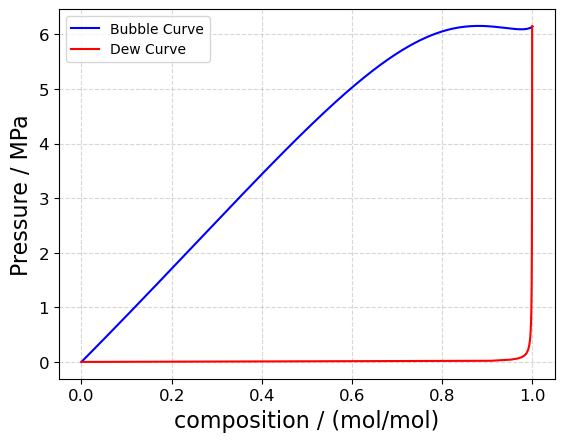

In [101]:
import PyPlot; const plt = PyPlot
using Clapeyron
"""
N = 300
T = 313.15

# 1. Menaikkan rentang batas atas X sedikit (misal ke 0.95 atau 0.98) 
# agar kurva puncak kritisnya bisa terhitung dan menutup sempurna.
x = range(1e-8, 1, length=N)

p = zeros(N)
y = zeros(N)

# Inisialisasi variabel v0 untuk menampung tebakan awal secara kontinu
v0 = []

# 2. Perulangan dengan proteksi try-catch
for j in 1:N
    try
        if j == 1
            # Iterasi pertama menggunakan tebakan default Clapeyron
            bub = bubble_pressure(model_opt, T, [x[j], 1-x[j]])
            p[j] = bub[1]
            y[j] = bub[4][1]
            
            # Simpan tebakan awal untuk iterasi berikutnya
            v0 = [log10(bub[2]), log10(bub[3]), bub[4][1], bub[4][2]]
        else
            # Iterasi selanjutnya memanfaatkan nilai v0 dari titik sebelumnya
            bub = bubble_pressure(model_opt, T, [x[j], 1-x[j]]; v0=v0)
            p[j] = bub[1]
            y[j] = bub[4][1]
            
            # Perbarui nilai v0 dengan hasil konvergensi terbaru
            v0 = [log10(bub[2]), log10(bub[3]), bub[4][1], bub[4][2]]
        end
    catch e
        # JIKA solver gagal konvergen di dekat titik kritis, titik tersebut 
        # akan diisi dengan NaN (Not a Number) agar kode TIDAK crash/eror,
        # dan grafik Python tetap bisa menggambar bagian yang sukses.
        p[j] = NaN
        y[j] = NaN
    end
end
"""
N    = 401
idxend = N
T    = 298.15

x    = LinRange(0., 1.,  N)
p    = zeros(N)
y    = zeros(N)

v0 = nothing
for i in 1:N
    if i==1
        bub = bubble_pressure(model, T, [x[i], 1-x[i]])
        p[i] = bub[1]
        y[i] = bub[4][1]
        v0   = vcat(log10.([bub[2],bub[3]]),[x[i+1],1-x[i+1]])
    else
        bub = bubble_pressure(model, T, [x[i], 1-x[i]]; v0 = v0)
        p[i] = bub[1]
        y[i] = bub[4][1]
        v0   = vcat(log10.([bub[2],bub[3]]),bub[4])
        if abs(y[i] - x[i])/x[i] < 1e-3
            idxend = i
            break
        end
    end
end

# 3. Bagian pembuatan grafik (Plotting)
plt.clf()
plt.plot(x, p./1e6, color="blue", label="Bubble Curve")
plt.plot(y, p./1e6, color="red", label="Dew Curve")
plt.xlabel("composition / (mol/mol)", fontsize=16)
plt.ylabel("Pressure / MPa", fontsize=16)
plt.xlim()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend()
plt.grid(true, linestyle="--", alpha=0.5) # opsional: menambahkan grid tipis agar rapi

In [102]:
using CSV, DataFrames, Printf

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [103]:
aard_p   = calculate_AAD(model_opt, "vlep_aceticacid.csv", vle_p)


=== AAD: vlep_aceticacid.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0000      2096.000000   2077.366388   0.8890  
0.0344      340000.000000  310850.337702  8.5734  
0.0445      440000.000000  401745.576701  8.6942  
0.0623      600000.000000  562166.136469  6.3056  
0.0688      660000.000000  620813.046504  5.9374  
0.0828      780000.000000  747236.312435  4.2005  
0.1006      940000.000000  908156.378864  3.3876  
0.1227      1140000.000000  1108166.360407  2.7924  
0.1509      1390000.000000  1363580.442020  1.9007  
0.1885      1680000.000000  1704099.973778  1.4345  
0.2315      2040000.000000  2092725.451707  2.5846  
0.2875      2460000.000000  2595761.908105  5.5188  
0.3500      2920000.000000  3149547.589434  7.8612  
0.4127      3390000.000000  3691681.093955  8.8991  
0.4915      3850000.000000  4342675.805138  12.7968 
0.5872      4430000.000000  5060595.564921  14.2347 
0.6834      4970000.000000  5652832.675350  13.7391 
0.7541      5370000.000

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


6.711576370591615

In [104]:
aard_p   = calculate_AAD(model_opt, "vley_aceticacid.csv", vle_y)


=== AAD: vley_aceticacid.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0344      0.965000      0.993156      2.9177  
0.0445      0.967000      0.994689      2.8634  
0.0623      0.975000      0.996185      2.1728  
0.0688      0.976000      0.996539      2.1044  
0.0828      0.977000      0.997112      2.0586  
0.1006      0.981000      0.997611      1.6933  
0.1227      0.984000      0.998029      1.4257  
0.1509      0.984000      0.998384      1.4618  
0.1885      0.984000      0.998691      1.4930  
0.2315      0.986000      0.998919      1.3102  
0.2875      0.990000      0.999111      0.9203  
0.3500      0.988000      0.999249      1.1386  
0.4127      0.988000      0.999343      1.1481  
0.4915      0.988000      0.999422      1.1561  
0.5872      0.988000      0.999481      1.1620  
0.6834      0.989000      0.999513      1.0630  
0.7541      0.989000      0.999525      1.0642  
AARD = 1.5972%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


1.597243915767026